In [71]:
import pandas as pd

level2 = pd.read_csv("../data/train_level2_cleaned.csv")

print("Shape:", level2.shape)

Shape: (11112, 8)


In [72]:
level2["Route"] = (
    level2["Start_Station"].astype(str)
    + " → "
    + level2["End_Station"].astype(str)
)

print(level2[["Train_No", "Start_Station", "End_Station", "Route"]].head())

   Train_No Start_Station   End_Station                        Route
0       107  SAWANTWADI R   MADGOAN JN.   SAWANTWADI R → MADGOAN JN.
1       108   MADGOAN JN.  SAWANTWADI R   MADGOAN JN. → SAWANTWADI R
2       128   MADGOAN JN.   CHHATRAPATI    MADGOAN JN. → CHHATRAPATI
3       290  DELHI-SAFDAR  DELHI-SAFDAR  DELHI-SAFDAR → DELHI-SAFDAR
4       401    AURANGABAD  VARANASI JN.    AURANGABAD → VARANASI JN.


In [73]:
route_counts = (
    level2.groupby("Route")
    .size()
    .reset_index(name="Train_Count")
    .sort_values("Train_Count", ascending=False)
)

route_counts.head(10)

,Route,Train_Count
926,CHENNAI BEAC → TAMBARAM,137
4397,TAMBARAM → CHENNAI BEAC,137
1125,CST-MUMBAI → PANVEL,94
3488,PANVEL → CST-MUMBAI,93
3889,RAVLI JN → CST-MUMBAI,90
1127,CST-MUMBAI → RAVLI JN,90
4713,VELACHEERY → CHENNAI BEAC,89
930,CHENNAI BEAC → VELACHEERY,87
1130,CST-MUMBAI → THANE,77
4440,THANE → CST-MUMBAI,72


In [74]:
print(level2.dtypes)

Train_No            int64
Start_Station         str
End_Station           str
Start_Departure       str
End_Arrival           str
Total_Distance      int64
Number_of_Stops     int64
Journey_Duration      str
Route                 str
dtype: object


In [75]:
print(level2["Journey_Duration"].head())
print(level2["Journey_Duration"].dtype)

0    0 days 01:45:00
1    0 days 01:55:00
2    0 days 22:05:00
3    5 days 08:00:00
4    1 days 12:30:00
Name: Journey_Duration, dtype: str
str


In [76]:
level2["Journey_Duration"] = pd.to_timedelta(
    level2["Journey_Duration"]
)

print(level2["Journey_Duration"].dtype)

timedelta64[us]


In [77]:
route_duration = (
    level2.groupby("Route")["Journey_Duration"]
    .mean()
    .reset_index(name="Average_Journey_Duration")
    .sort_values("Average_Journey_Duration", ascending=False)
)

route_duration.head(10)

,Route,Average_Journey_Duration
1294,DELHI-SAFDAR → DELHI-SAFDAR,5 days 08:00:00
1374,DIBRUGARH → KANNIYAKUMAR,3 days 10:45:00
2379,KANNIYAKUMAR → DIBRUGARH,3 days 07:40:00
4579,TRIVANDRUM C → SILCHAR,3 days 03:51:40
4276,SILCHAR → TRIVANDRUM C,3 days 02:45:00
2387,KANNIYAKUMAR → SHRI MATA VA,3 days 01:05:00
4258,SHRI MATA VA → MANGALORE CE,3 days 00:50:00
4255,SHRI MATA VA → KANNIYAKUMAR,3 days 00:00:00
2968,MANGALORE CE → SHRI MATA VA,2 days 22:15:00
1379,DIBRUGARH → TAMBARAM,2 days 21:30:00


In [78]:
route_duration.sort_values(
    "Average_Journey_Duration",
    ascending=True
).head(10)

,Route,Average_Journey_Duration
2450,KARJAT → PALASDARI,0 days 00:05:00
3458,PALASDARI → KARJAT,0 days 00:07:00
4547,TIRUVALLUR → KADAMBATTUR,0 days 00:10:00
184,AMBERNATH → KALYAN JN,0 days 00:12:22.105263
2342,KALYAN JN → AMBERNATH,0 days 00:12:43.076923
499,BARASAT JN. → DATTAPUKUR,0 days 00:13:00
2547,KHARAGPUR → HIJLI,0 days 00:13:30
1850,HIJLI → KHARAGPUR,0 days 00:15:00
4345,SONARPUR JN. → BARUIPUR JN.,0 days 00:15:00
194,AMRAVATI → BADNERA JN.,0 days 00:15:00


In [79]:
station_traffic = (
    pd.concat([
        level2[["Start_Station"]].rename(columns={"Start_Station": "Station"}),
        level2[["End_Station"]].rename(columns={"End_Station": "Station"})
    ])
    .groupby("Station")
    .size()
    .reset_index(name="Train_Traffic")
    .sort_values("Train_Traffic", ascending=False)
)

station_traffic.head(10)

,Station,Train_Traffic
225,CST-MUMBAI,1027
781,SEALDAH,745
202,CHENNAI BEAC,681
376,HOWRAH JN.,676
430,KALYAN JN,569
853,THANE,380
667,PANVEL,285
842,TAMBARAM,280
590,MOOR MARKET,267
906,VELACHEERY,233


In [80]:
station_traffic.sort_values(
    "Train_Traffic",
    ascending=True
).head(10)

,Station,Train_Traffic
899,VANGAICHUNGP,1
79,BANDA JN,1
830,SRIKAKULAM R,1
285,DOMBIVLI CTL,1
857,THIVIM,1
191,CHAMPAHATI,1
869,TIRUNINRAVUR,1
894,URKURA,1
680,PAYYANUR,1
664,PANJIPARA,1


In [81]:
print(
    level2[["Total_Distance", "Journey_Duration"]].describe()
)

       Total_Distance        Journey_Duration
count    11112.000000                   11112
mean       348.671256  0 days 07:13:50.766738
std        595.837412  0 days 11:07:37.967321
min          1.000000         0 days 00:05:00
25%         38.000000         0 days 01:03:00
50%         82.000000         0 days 02:15:00
75%        324.000000         0 days 07:30:00
max       4260.000000         5 days 08:00:00


In [82]:
distance_duration_corr = level2[
    ["Total_Distance", "Journey_Duration"]
].copy()

distance_duration_corr["Journey_Duration_Hours"] = (
    distance_duration_corr["Journey_Duration"]
    / pd.Timedelta(hours=1)
)

print(
    distance_duration_corr[
        ["Total_Distance", "Journey_Duration_Hours"]
    ].corr()
)

                        Total_Distance  Journey_Duration_Hours
Total_Distance                1.000000                0.983518
Journey_Duration_Hours        0.983518                1.000000


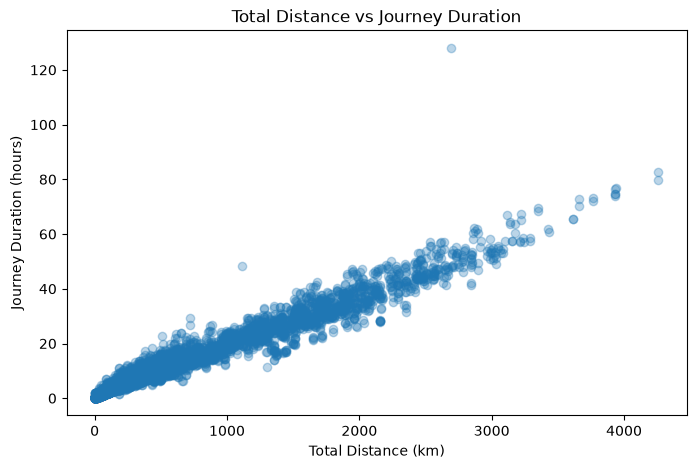

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    level2["Total_Distance"],
    level2["Journey_Duration"] / pd.Timedelta(hours=1),
    alpha=0.3
)

plt.xlabel("Total Distance (km)")
plt.ylabel("Journey Duration (hours)")
plt.title("Total Distance vs Journey Duration")

plt.show()

## Level 3 Summary Insights

- Journey duration varies substantially across different train routes, ranging from a few minutes to several days.
- CST-MUMBAI has the highest train traffic among the start/end stations, with 1,027 train associations.
- Several stations have very low traffic, with only one train association in the dataset.
- Total distance and journey duration show a very strong positive relationship, with a correlation coefficient of 0.9835.
- Longer-distance train journeys generally require longer journey durations.
- Some unusually long journey durations are present and should be interpreted carefully because the original dataset contains time-of-day values without calendar dates.

In [84]:
import pandas as pd

level2 = pd.read_csv("../data/train_level2_cleaned.csv")

level2["Journey_Duration"] = pd.to_timedelta(
    level2["Journey_Duration"]
)

print("Shape:", level2.shape)
print(level2["Journey_Duration"].dtype)

Shape: (11112, 8)
timedelta64[us]


In [85]:
level2["Route"] = (
    level2["Start_Station"].astype(str)
    + " → "
    + level2["End_Station"].astype(str)
)

print(level2[["Start_Station", "End_Station", "Route"]].head())

  Start_Station   End_Station                        Route
0  SAWANTWADI R   MADGOAN JN.   SAWANTWADI R → MADGOAN JN.
1   MADGOAN JN.  SAWANTWADI R   MADGOAN JN. → SAWANTWADI R
2   MADGOAN JN.   CHHATRAPATI    MADGOAN JN. → CHHATRAPATI
3  DELHI-SAFDAR  DELHI-SAFDAR  DELHI-SAFDAR → DELHI-SAFDAR
4    AURANGABAD  VARANASI JN.    AURANGABAD → VARANASI JN.


In [86]:
route_duration = (
    level2.groupby("Route")["Journey_Duration"]
    .mean()
    .reset_index(name="Average_Journey_Duration")
    .sort_values("Average_Journey_Duration", ascending=False)
)

top_routes = route_duration.head(10).copy()

top_routes["Average_Journey_Hours"] = (
    top_routes["Average_Journey_Duration"]
    / pd.Timedelta(hours=1)
)

top_routes

,Route,Average_Journey_Duration,Average_Journey_Hours
1294,DELHI-SAFDAR → DELHI-SAFDAR,5 days 08:00:00,128.000000
1374,DIBRUGARH → KANNIYAKUMAR,3 days 10:45:00,82.750000
2379,KANNIYAKUMAR → DIBRUGARH,3 days 07:40:00,79.666667
4579,TRIVANDRUM C → SILCHAR,3 days 03:51:40,75.861111
4276,SILCHAR → TRIVANDRUM C,3 days 02:45:00,74.750000
2387,KANNIYAKUMAR → SHRI MATA VA,3 days 01:05:00,73.083333
4258,SHRI MATA VA → MANGALORE CE,3 days 00:50:00,72.833333
4255,SHRI MATA VA → KANNIYAKUMAR,3 days 00:00:00,72.000000
2968,MANGALORE CE → SHRI MATA VA,2 days 22:15:00,70.250000
1379,DIBRUGARH → TAMBARAM,2 days 21:30:00,69.500000


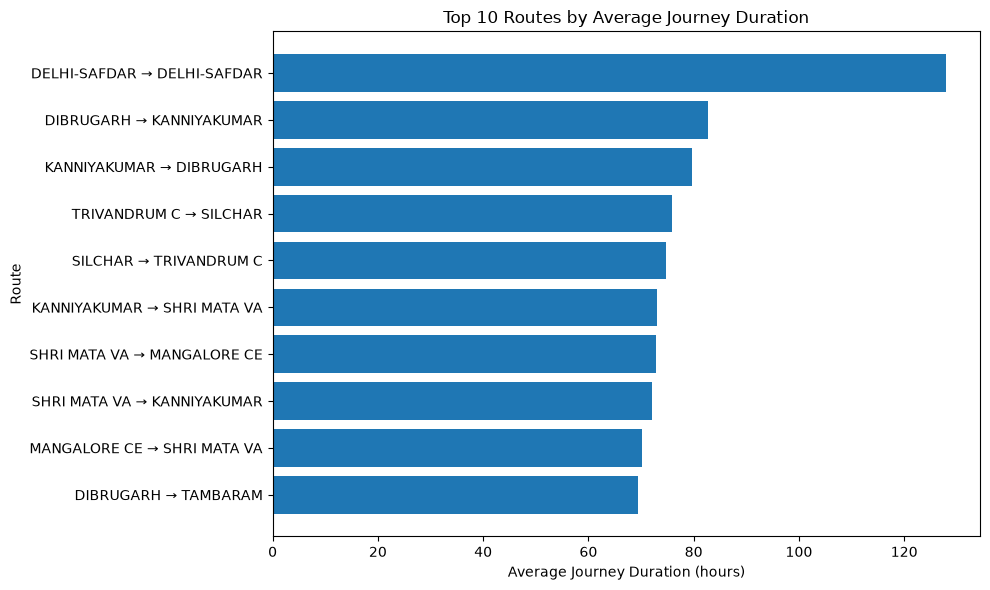

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_routes["Route"],
    top_routes["Average_Journey_Hours"]
)

plt.xlabel("Average Journey Duration (hours)")
plt.ylabel("Route")
plt.title("Top 10 Routes by Average Journey Duration")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Pattern Analysis: Journey Duration Across Routes

The visualization shows substantial variation in average journey duration across train routes. The DELHI-SAFDAR → DELHI-SAFDAR route has the highest reconstructed average journey duration at 128 hours, followed by DIBRUGARH → KANNIYAKUMAR at 82.75 hours.

Most of the routes shown in the chart are long-distance routes and have average journey durations of more than 69 hours. This indicates that route characteristics and travel distance have a major influence on journey duration.

The unusually long durations should be interpreted carefully because the original dataset contains time-of-day information but does not provide calendar dates. Therefore, multi-day journey durations were reconstructed from the available station times.

In [88]:
station_traffic = (
    pd.concat([
        level2[["Start_Station"]].rename(columns={"Start_Station": "Station"}),
        level2[["End_Station"]].rename(columns={"End_Station": "Station"})
    ])
    .groupby("Station")
    .size()
    .reset_index(name="Train_Traffic")
    .sort_values("Train_Traffic", ascending=False)
)

station_traffic.head(10)

,Station,Train_Traffic
225,CST-MUMBAI,1027
781,SEALDAH,745
202,CHENNAI BEAC,681
376,HOWRAH JN.,676
430,KALYAN JN,569
853,THANE,380
667,PANVEL,285
842,TAMBARAM,280
590,MOOR MARKET,267
906,VELACHEERY,233


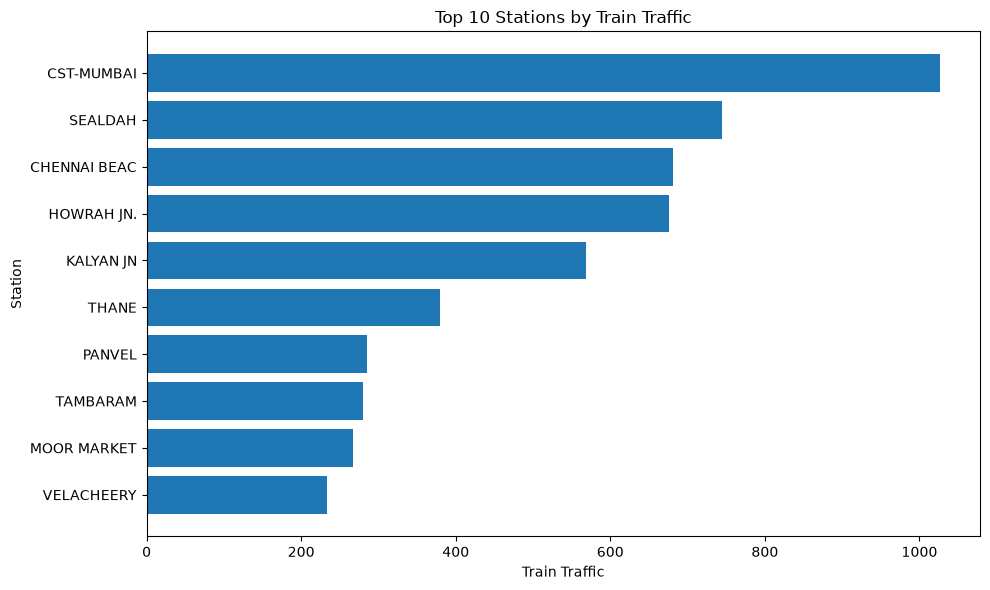

In [89]:
top_stations = station_traffic.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_stations["Station"],
    top_stations["Train_Traffic"]
)

plt.xlabel("Train Traffic")
plt.ylabel("Station")
plt.title("Top 10 Stations by Train Traffic")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Pattern Analysis: Station-wise Train Traffic

The station-wise visualization shows that train traffic is concentrated at a small number of stations. CST-MUMBAI has the highest train traffic with 1,027 train associations, followed by SEALDAH with 745.

CHENNAI BEAC, HOWRAH JN., and KALYAN JN. also show relatively high train traffic. The traffic decreases considerably among the remaining stations in the top 10.

This analysis indicates that some stations play a more prominent role as train journey endpoints in the dataset.

Note: Train traffic here represents the number of train-level records associated with a station as a starting or ending station. It does not represent every train passing through the station.

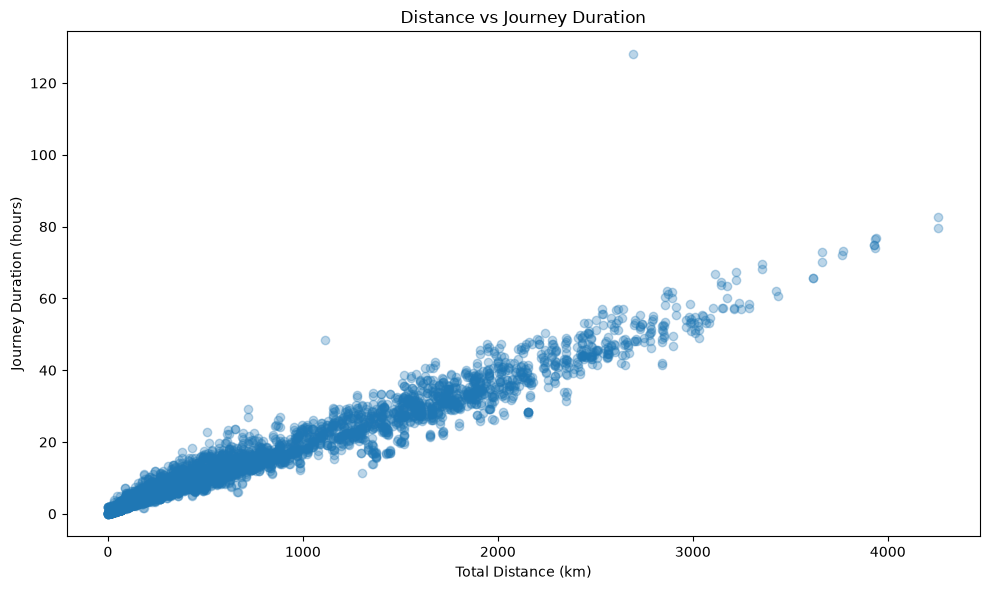

In [90]:
plt.figure(figsize=(10, 6))

plt.scatter(
    level2["Total_Distance"],
    level2["Journey_Duration"] / pd.Timedelta(hours=1),
    alpha=0.3
)

plt.xlabel("Total Distance (km)")
plt.ylabel("Journey Duration (hours)")
plt.title("Distance vs Journey Duration")

plt.tight_layout()
plt.show()

### Pattern Analysis: Distance vs Journey Duration

The scatter plot shows a strong positive and approximately linear relationship between total distance and journey duration. As the distance traveled increases, the journey duration generally increases.

Most observations follow the overall upward trend, although a few outliers with unusually long durations are present. The correlation coefficient of 0.9835 further supports this strong relationship.

This relationship is particularly relevant to the prediction stage because total distance is one of the required features for the Linear Regression model.

## Level 4 Summary

- Journey duration varies substantially across different train routes, with long-distance routes generally requiring more time.
- Train traffic is concentrated at a smaller number of stations, with CST-MUMBAI having the highest train traffic in the analyzed dataset.
- The scatter plot shows a strong positive and approximately linear relationship between total distance and journey duration.
- The distance-duration correlation of 0.9835 supports the visual observation of a strong relationship.
- A few outliers are visible in the visualizations and should be interpreted carefully.
- The absence of calendar dates in the original dataset means that reconstructed multi-day journey durations should be treated as an important data limitation.
- These findings provide the basis for the next stage of the project: predicting journey duration using Linear Regression.

In [91]:
model_data = level2[
    ["Total_Distance", "Number_of_Stops", "Journey_Duration"]
].copy()

model_data["Journey_Duration_Hours"] = (
    model_data["Journey_Duration"]
    / pd.Timedelta(hours=1)
)

model_data = model_data[
    ["Total_Distance", "Number_of_Stops", "Journey_Duration_Hours"]
]

print("Shape:", model_data.shape)
print(model_data.head())

Shape: (11112, 3)
   Total_Distance  Number_of_Stops  Journey_Duration_Hours
0              78                4                1.750000
1              83                4                1.916667
2             978               22               22.083333
3            2694               14              128.000000
4            1618               12               36.500000


In [92]:
X = model_data[
    ["Total_Distance", "Number_of_Stops"]
]

y = model_data[
    "Journey_Duration_Hours"
]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
   Total_Distance  Number_of_Stops
0              78                4
1              83                4
2             978               22
3            2694               14
4            1618               12

Target (y):
0      1.750000
1      1.916667
2     22.083333
3    128.000000
4     36.500000
Name: Journey_Duration_Hours, dtype: float64

X shape: (11112, 2)
y shape: (11112,)


In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (8889, 2)
Testing features: (2223, 2)
Training target: (8889,)
Testing target: (2223,)


In [94]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [95]:
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
[ 0.82614616  0.36165729  1.82430304  3.65200142  1.50018664  2.36874374
 -0.1287796   1.68599155 31.51669709 26.09617714]


In [96]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("MAE in minutes:", mae * 60)

Mean Absolute Error (MAE): 0.974418861221199
MAE in minutes: 58.46513167327194


In [97]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)
print("RMSE in minutes:", rmse * 60)

Root Mean Squared Error (RMSE): 2.232855382289485
RMSE in minutes: 133.9713229373691


## Level 5 Model Evaluation

The Linear Regression model was trained using `Total_Distance` and `Number_of_Stops` as input features and `Journey_Duration_Hours` as the target variable.

The model was evaluated on 2,223 test journeys using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

- **MAE:** 0.9744 hours (approximately 58.47 minutes)
- **RMSE:** 2.2329 hours (approximately 133.97 minutes)

The MAE indicates that the model's predictions differ from the actual journey durations by approximately 58 minutes on average.

The RMSE is higher than the MAE because RMSE gives greater importance to larger prediction errors. This indicates that some journeys have considerably larger prediction errors than the typical error.

Overall, the Linear Regression model provides a baseline prediction of journey duration using total distance and number of stops.

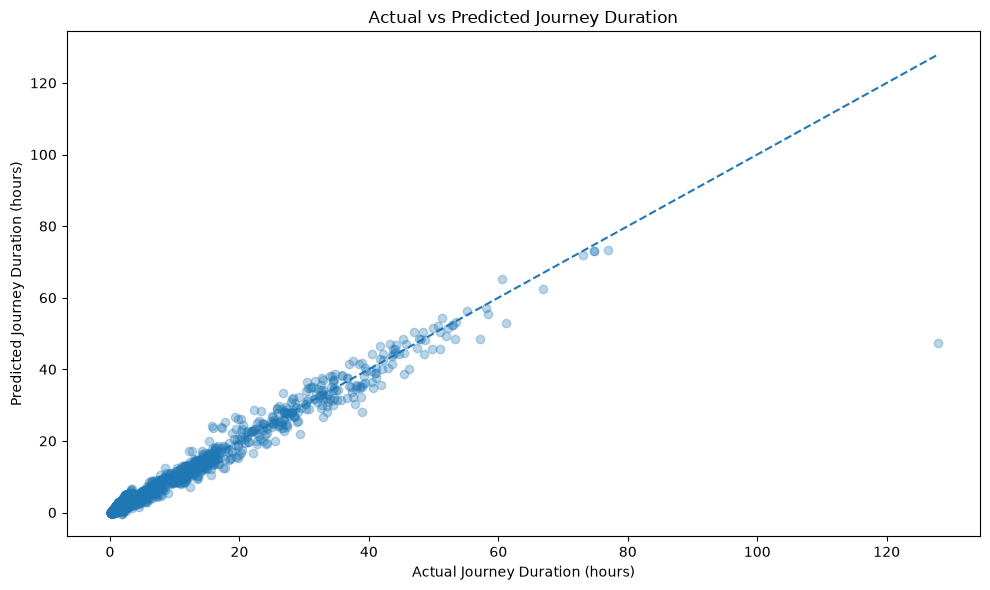

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

# Reference line: perfect prediction
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Journey Duration (hours)")
plt.ylabel("Predicted Journey Duration (hours)")
plt.title("Actual vs Predicted Journey Duration")

plt.tight_layout()
plt.show()

### Actual vs Predicted Journey Duration

The actual versus predicted plot shows a strong positive relationship between the actual journey duration and the duration predicted by the Linear Regression model.

The dashed diagonal line represents perfect predictions, where the actual and predicted journey durations are equal. Most observations are relatively close to this line, particularly for shorter and medium-duration journeys.

For longer journeys, the prediction errors become more noticeable. A few large deviations from the reference line are visible, including an observation with an actual journey duration of approximately 128 hours and a predicted duration of approximately 47 hours.

These larger errors are consistent with the RMSE being higher than the MAE and indicate that the model does not predict all long-duration journeys accurately.

## Final Project Summary

This project analyzed train route data and developed a Linear Regression model for predicting journey duration.

The original dataset contained station-level train records. During data cleaning and feature engineering, the station-level data was transformed into train-level journey records using total distance, number of stops, start station, end station, and reconstructed journey duration.

Exploratory analysis showed substantial variation in journey durations and train traffic across stations. Total distance and journey duration showed a very strong positive correlation of 0.9835.

For prediction, Total Distance and Number of Stops were used as features, while Journey Duration in hours was used as the target variable. The data was divided into 80% training data and 20% testing data, and a Linear Regression model was trained.

The model achieved:

- **MAE:** 0.9744 hours (approximately 58.47 minutes)
- **RMSE:** 2.2329 hours (approximately 133.97 minutes)

The actual versus predicted visualization shows that the model generally follows the overall relationship between journey distance and duration, particularly for shorter and medium-duration journeys. However, larger errors occur for some long-duration journeys.

An important limitation of the project is that the original dataset contains time-of-day information but does not provide calendar dates. Therefore, multi-day journey durations were reconstructed from the available station times and should be interpreted with caution.

In [99]:
def predict_journey_duration(distance_km, number_of_stops):
    input_data = pd.DataFrame({
        "Total_Distance": [distance_km],
        "Number_of_Stops": [number_of_stops]
    })

    prediction = model.predict(input_data)[0]

    return prediction


# Example prediction
distance = 500
stops = 10

predicted_hours = predict_journey_duration(
    distance,
    stops
)

print(f"Predicted Journey Duration: {predicted_hours:.2f} hours")
print(f"Approximately: {predicted_hours * 60:.0f} minutes")

Predicted Journey Duration: 9.15 hours
Approximately: 549 minutes
